In [1]:
import ee 
import luma_ge
luma_ge.authenticate_manually()
import geemap


Successfully saved authorization token.


# Step 1: Select best avaliable imagery

In [4]:
#retrieve aoi from assets
aoi = ee.FeatureCollection('projects/ee-agilfahrezy60/assets/Sesi1_AOI_Kambera_NTT')
#import required library and initialize them
from luma_ge.data_acquisition import Reflectance_Data, Reflectance_Stats, final_Image
optical_reflectance = Reflectance_Data()
composite = final_Image()
#search cloud free data
start = '2025-01-01'
end = '2025-12-31'
#get the image collection and corresponding statistics
landsat_9, meta = optical_reflectance.get_optical_data(aoi, start, end, optical_data='L9_SR', 
                                                           cloud_cover=20, compute_detailed_stats=False)
# Compute the median composite
landsat_median = landsat_9.median().clip(aoi)
#visualization parameter
l8_sr_visparam = {'min': 0,'max': 0.4,'gamma': [0.95, 1.1, 1],'bands':['NIR', 'RED', 'GREEN']}
#Add the data to the map
Map = geemap.Map()
Map.addLayer(landsat_median, l8_sr_visparam, 'L8 SR Image Collection')
# set center of the map in the area of interest
Map.centerObject(aoi, 12)
Map

2026-08-20 13:48:34,015 - Reflectance_Data - INFO - ReflectanceData initialized.
2026-08-20 13:48:34,017 - final_Image - INFO - final_Image creation initialized.
2026-08-20 13:48:34,017 - Reflectance_Data - INFO - Starting data fetch for Landsat 9 Operational Land Imager-2 Surface Reflectance
2026-08-20 13:48:34,017 - Reflectance_Data - INFO - Date range: 2025-01-01 to 2025-12-31
2026-08-20 13:48:34,017 - Reflectance_Data - INFO - Cloud cover threshold: 20%
2026-08-20 13:48:34,018 - Reflectance_Data - INFO - detailed statistics will not be computed
2026-08-20 13:48:34,018 - Reflectance_Stats - INFO - Reflectance Stats initialized.
2026-08-20 13:48:34,018 - Reflectance_Data - INFO - Filtered collection created (use compute_detailed_stats=True for more information)


Map(center=[-9.704356522667766, 120.27216753241345], controls=(WidgetControl(options=['position', 'transparent…

# Step 2: Feature Engineering
## Topography based predictor

In [5]:
#import and initialize the required modules
from luma_ge.predictor import terrain_calculator, SpectralCalculator, distance_calculator
dist_calc = distance_calculator()
terrain_calc = terrain_calculator()
spectral_calc = SpectralCalculator()
#Define DEM
#retrieve topography based predictors
dem_source = 'NASADEM'
elevation = terrain_calc.calculate_elevation(aoi, dem_source=dem_source) # type: ignore
slope = terrain_calc.calculate_slope(aoi, dem_source=dem_source) # type: ignore
aspect = terrain_calc.calculate_aspect(aoi, dem_source=dem_source) # type: ignore
#Visualize terrain layers on the map
terrain_vis = {
    'min': 0,
    'max': 500,
    'palette': ['black', 'blue', 'green', 'yellow', 'red']}
slope_vis = {
    'min': 0,
    'max': 45,
    'palette': ['white', 'lightblue', 'green', 'yellow', 'red']}
aspect_vis = {
    'min': 0,
    'max': 360,
    'palette': ['white', 'blue', 'green', 'yellow', 'red', 'purple']
}
m = geemap.Map()
m.addLayer(elevation, terrain_vis, f"Elevation ({dem_source})")
m.addLayer(slope, slope_vis, f"Slope ({dem_source})")

2026-08-20 13:54:09,113 - luma_ge.predictor - INFO - Distance calculator initialized
2026-08-20 13:54:09,114 - luma_ge.predictor - INFO - Terrain calculator initialized
2026-08-20 13:54:11,340 - luma_ge.predictor - INFO - SpectralCalculator initialized
2026-08-20 13:54:11,341 - luma_ge.predictor - INFO - Calculating elevation layer using NASADEM DEM...
2026-08-20 13:54:11,342 - luma_ge.predictor - INFO - Successfully calculated elevation layer using NASADEM DEM
2026-08-20 13:54:11,342 - luma_ge.predictor - INFO - Calculating slope layer using NASADEM DEM...
2026-08-20 13:54:11,342 - luma_ge.predictor - INFO - Calculating elevation layer using NASADEM DEM...
2026-08-20 13:54:11,343 - luma_ge.predictor - INFO - Successfully calculated elevation layer using NASADEM DEM
2026-08-20 13:54:11,343 - luma_ge.predictor - INFO - Successfully calculated slope layer using NASADEM DEM
2026-08-20 13:54:11,344 - luma_ge.predictor - INFO - Calculating aspect layer using NASADEM DEM...
2026-08-20 13:54:

## Spectral Transformation

In [6]:
#Compute spectral indices from the optical collection
indices_to_compute = ['EVI', 'GBNDVI', 'MSAVI', 'GNDVI', 'SAVI', 'NDVI', 'MNDWI', 'NDBI', 'MBI', 'NDMI' ]
spectral_indices = spectral_calc.calculate_indices_with_collection(
    collection=landsat_9,
    aoi=aoi, # type: ignore
    index_list=indices_to_compute,
    reducer_method='mean'
)
print('Computed terrain layers: elevation, slope, aspect')
print('Computed spectral indices:', spectral_indices.bandNames().getInfo() if spectral_indices else 'failed')
if spectral_indices:
    ndvi_vis = {'min': -1, 'max': 1, 'palette': ['purple', 'white', 'green']}
    evi_vis = {'min': -1, 'max': 1, 'palette': ['navy', 'white', 'lime']}
    m.addLayer(spectral_indices.select('GBNDVI'), ndvi_vis, 'GBNDVI')
    m.addLayer(spectral_indices.select('EVI'), evi_vis, 'EVI')
m

2026-08-20 13:54:21,606 - luma_ge.predictor - INFO - Calculating spectral indices using map and mean reducer on collection
2026-08-20 13:54:21,606 - luma_ge.predictor - INFO - Using default coefficients where required
2026-08-20 13:54:21,607 - luma_ge.predictor - INFO - Retrieved default coefficients for EVI: {'g': 2.5, 'C1': 6.0, 'C2': 7.5, 'L': 1.0}
2026-08-20 13:54:21,608 - luma_ge.predictor - INFO - Added default coefficients for EVI: {'g': 2.5, 'C1': 6.0, 'C2': 7.5, 'L': 1.0}
2026-08-20 13:54:21,608 - luma_ge.predictor - INFO - Retrieved default coefficients for MSAVI: {'L': 0.5}
2026-08-20 13:54:21,608 - luma_ge.predictor - INFO - Added default coefficients for MSAVI: {'L': 0.5}
2026-08-20 13:54:21,608 - luma_ge.predictor - INFO - Retrieved default coefficients for SAVI: {'L': 0.5}
2026-08-20 13:54:21,608 - luma_ge.predictor - INFO - Added default coefficients for SAVI: {'L': 0.5}
2026-08-20 13:54:21,610 - luma_ge.predictor - INFO - Mapping index calculation over collection...
20

Computed terrain layers: elevation, slope, aspect
Computed spectral indices: ['EVI', 'GBNDVI', 'MSAVI', 'GNDVI', 'SAVI', 'NDVI', 'MNDWI', 'NDBI', 'MBI', 'NDMI']


Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

## Distance based predictor

In [7]:
#distance based predictors (5km buffer)
distance_predictor = dist_calc.calculate_distance_metrics(
    aoi = aoi.geometry(), max_dist = 50000, in_meters = True)

2026-08-20 13:54:40,186 - luma_ge.predictor - INFO - Calculating distance metrics (max_dist=50000, in_meters=True)...
2026-08-20 13:54:40,188 - luma_ge.predictor - INFO - Using meter-based distance calculation (slower but more accurate)
2026-08-20 13:54:40,188 - luma_ge.predictor - INFO - Processing coastline data...
2026-08-20 13:54:40,188 - luma_ge.predictor - INFO - Processing roads data...
2026-08-20 13:54:40,189 - luma_ge.predictor - INFO - Processing settlement data...
2026-08-20 13:54:40,191 - luma_ge.predictor - INFO - Computing distance transformations...
2026-08-20 13:54:40,191 - luma_ge.predictor - INFO - Successfully calculated distance metrics: dist_roads, dist_coast, dist_settlement


## Stack all of the predictors/features

In [8]:
#stack the predictors and the imagery
predictor_stack = landsat_median.addBands(spectral_indices).addBands(elevation).addBands(slope).addBands(aspect).addBands(distance_predictor).toFloat()
print('Final predictor stack bands:', predictor_stack.bandNames().getInfo() if predictor_stack else 'failed')

Final predictor stack bands: ['AEROSOL', 'BLUE', 'GREEN', 'RED', 'NIR', 'SWIR1', 'SWIR2', 'EVI', 'GBNDVI', 'MSAVI', 'GNDVI', 'SAVI', 'NDVI', 'MNDWI', 'NDBI', 'MBI', 'NDMI', 'elevation', 'slope', 'aspect', 'dist_roads', 'dist_coast', 'dist_settlement']


# Step 3: Extract the pixel value based on the training data

In [9]:
from luma_ge.classification import FeatureExtraction, Generate_LULC

labeled_roi = ee.FeatureCollection('projects/ee-agilfahrezy60/assets/Sesi1_Data_Latih_Kambera')
features = FeatureExtraction()
train, test = features.stratified_split(roi=labeled_roi, 
                                        image=predictor_stack, 
                                        class_prop='ID_Kelas', 
                                        train_ratio=0.7, 
                                        seed=42)

Stratified Random Split Training Pixel Size: 308
Stratified Random Split Testing Pixel Size: 152


# Step 4: Perform Recursive Feature Elimination

In [10]:
from luma_ge.predictor import RFEGEE
predictor_name = predictor_stack.bandNames().getInfo()
rfe = RFEGEE(
    training_data=train,  #Training data
    class_property='ID_Kelas',  #class ID property
    features=predictor_name,  #Pass list of band names, not the image
    n_features_to_select=15,  #how many features to select (?)
    step=1,  #how many features remove per iteration
    n_trees=100,  #Number of trees in Random Forest
    test_data=test, 
    seed=42,
    track_accuracy=True,  #Track accuracy to see how performance changes
    verbose=True  #Print progress
)
#run the RFE algorithm
rfe.fit()
print("\n" + "="*60)
print("RFE Execution Complete!")
print("="*60)

RFE initialized successfully!
Starting RFE with 23 features
Target: 15
--------------------------------------------------
Features: 23 | Acc: 0.8158
Removing: ['aspect', 'BLUE', 'RED', 'NDBI']
Features: 19 | Acc: 0.8289
Removing: ['NDVI', 'dist_roads']
Features: 17 | Acc: 0.8289
Removing: ['EVI']
Features: 16 | Acc: 0.8158
Removing: ['SAVI']
--------------------------------------------------
Selected features (15):
  - AEROSOL
  - GREEN
  - NIR
  - SWIR1
  - SWIR2
  - GBNDVI
  - MSAVI
  - GNDVI
  - MNDWI
  - MBI
  - NDMI
  - elevation
  - slope
  - dist_coast
  - dist_settlement

RFE Execution Complete!


# Step 5: Evaluate the result

In [11]:
#Get selected features
selected_features = rfe.get_selected_features()
print(f"Selected Features ({len(selected_features)}):")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i}. {feature}")

#feature rankings (1 = selected, 2+ = order of elimination)
rankings = rfe.get_ranking()
print(f"\nFeature Rankings:")
for feature, rank in sorted(rankings.items(), key=lambda x: x[1]):
    print(f"  {feature}: Rank {rank}")
#support (boolean dict of selected features)
support = rfe.get_support()
print(f"\nFeature Support (Selected/Not Selected):")
for feature, selected in support.items():
    status = "✓ Selected" if selected else "✗ Eliminated"
    print(f"  {feature}: {status}")

Selected Features (15):
  1. AEROSOL
  2. GREEN
  3. NIR
  4. SWIR1
  5. SWIR2
  6. GBNDVI
  7. MSAVI
  8. GNDVI
  9. MNDWI
  10. MBI
  11. NDMI
  12. elevation
  13. slope
  14. dist_coast
  15. dist_settlement

Feature Rankings:
  AEROSOL: Rank 1
  GREEN: Rank 1
  NIR: Rank 1
  SWIR1: Rank 1
  SWIR2: Rank 1
  GBNDVI: Rank 1
  MSAVI: Rank 1
  GNDVI: Rank 1
  MNDWI: Rank 1
  MBI: Rank 1
  NDMI: Rank 1
  elevation: Rank 1
  slope: Rank 1
  dist_coast: Rank 1
  dist_settlement: Rank 1
  aspect: Rank 2
  BLUE: Rank 3
  RED: Rank 4
  NDBI: Rank 5
  NDVI: Rank 6
  dist_roads: Rank 7
  EVI: Rank 8
  SAVI: Rank 9

Feature Support (Selected/Not Selected):
  AEROSOL: ✓ Selected
  BLUE: ✗ Eliminated
  GREEN: ✓ Selected
  RED: ✗ Eliminated
  NIR: ✓ Selected
  SWIR1: ✓ Selected
  SWIR2: ✓ Selected
  EVI: ✗ Eliminated
  GBNDVI: ✓ Selected
  MSAVI: ✓ Selected
  GNDVI: ✓ Selected
  SAVI: ✗ Eliminated
  NDVI: ✗ Eliminated
  MNDWI: ✓ Selected
  NDBI: ✗ Eliminated
  MBI: ✓ Selected
  NDMI: ✓ Selected
  

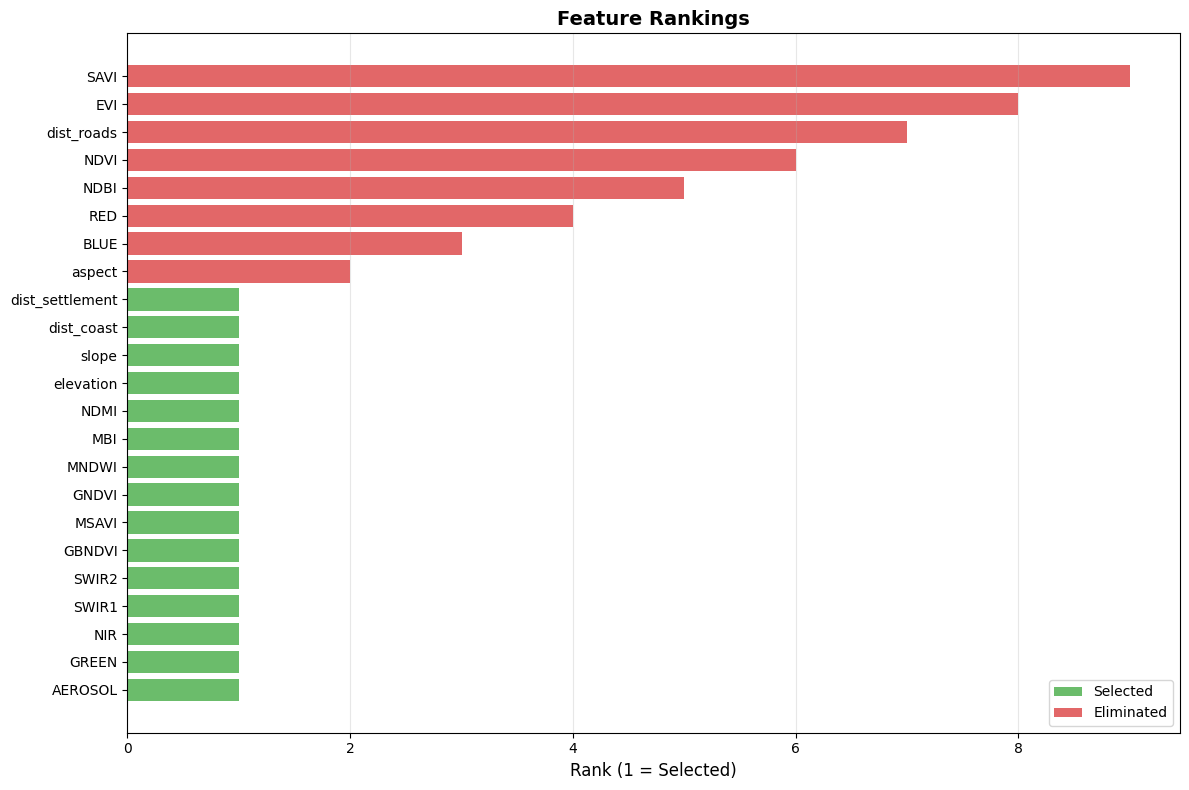

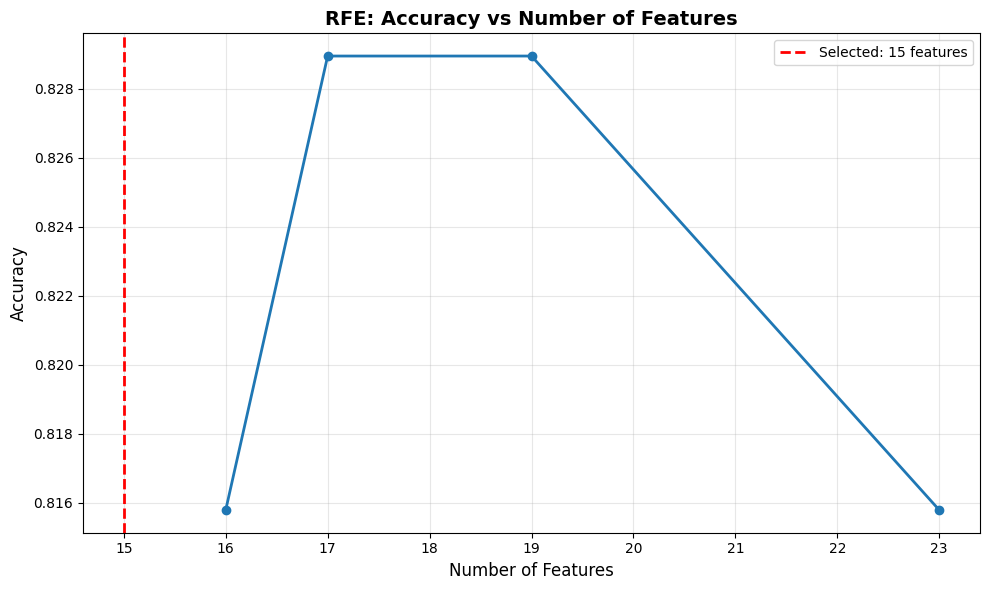

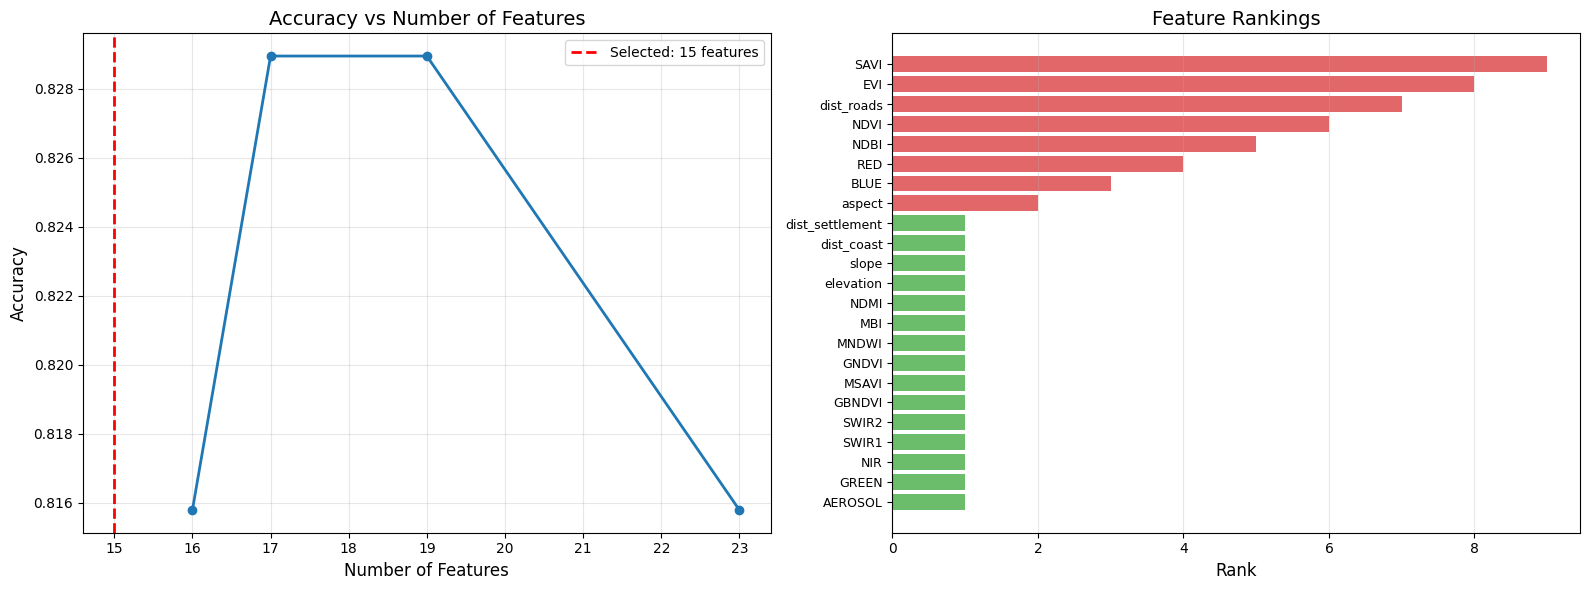

In [12]:
import matplotlib.pyplot as plt
#Feature Rankings
fig1 = rfe.plot_feature_rankings(figsize=(12, 8))
plt.show()
#Accuracy vs Number of Features (only work if track accuracy is enable)
if rfe.accuracy_history_:
    fig2 = rfe.plot_accuracy_curve(figsize=(10, 6))
    plt.show()
# Combined Summary
fig3 = rfe.plot_rfe_summary(figsize=(16, 6))
plt.show()

In [13]:
results_df = rfe.get_results_dataframe()
print("Results DataFrame:")
print(results_df.to_string())

# Accuracy history (if available)
if rfe.accuracy_history_:
    accuracy_df = rfe.get_accuracy_dataframe()
    print("\nAccuracy History:")
    print(accuracy_df.to_string())

Results DataFrame:
            Feature  Rank  Selected        Status  Final_Importance
0           AEROSOL     1      True    ✅ Selected         43.359527
1             GREEN     1      True    ✅ Selected         45.055749
2             SWIR1     1      True    ✅ Selected         39.306803
3               NIR     1      True    ✅ Selected         39.914865
4             SWIR2     1      True    ✅ Selected         43.892030
5             GNDVI     1      True    ✅ Selected         50.713267
6             MSAVI     1      True    ✅ Selected         43.745140
7            GBNDVI     1      True    ✅ Selected         41.313353
8               MBI     1      True    ✅ Selected         44.411681
9             MNDWI     1      True    ✅ Selected         58.041451
10        elevation     1      True    ✅ Selected         50.169609
11  dist_settlement     1      True    ✅ Selected         49.736799
12       dist_coast     1      True    ✅ Selected         61.300291
13            slope     1    

# Step 6: Retrieve the final predictor (optimum features) and perform classification

In [ ]:
# Build the final predictor stack from the optimum RFE features
selected_features = rfe.get_selected_features()
final_predictor_stack = predictor_stack.select(selected_features).toFloat()
print(f"Final features ({len(selected_features)}):")
print(final_predictor_stack.bandNames().getInfo())
#Re-extract training pixels for the selected features
final_training, final_test = features.stratified_split(roi=labeled_roi,
                                                class_prop = 'ID_Kelas',
                                                image=final_predictor_stack,
                                                pixel_size=30,
                                                train_ratio=0.7,
                                                seed=42)

#perform the classification using final predictor stack
lulc_generator = Generate_LULC()
final_classification = lulc_generator.hard_classification(
    training_data=final_training,
    class_property='ID_Kelas',
    image=final_predictor_stack,
    ntrees=100,
    seed=42
)

classification_vis = {
    'min': 1,
    'max': 6,
    'palette': ['419BDF', '397D49', '88B053', '7A87C6', 'E49635', 'DFC35A']
}
m.addLayer(final_classification, classification_vis, 'Luma-Ge Classification (RFE Features)')
m.centerObject(aoi, 12)
m

Final features (15):
['AEROSOL', 'GREEN', 'NIR', 'SWIR1', 'SWIR2', 'GBNDVI', 'MSAVI', 'GNDVI', 'MNDWI', 'MBI', 'NDMI', 'elevation', 'slope', 'dist_coast', 'dist_settlement']


Map(bottom=69188.0, center=[-9.704356522667766, 120.27216753241345], controls=(WidgetControl(options=['positio…